# Домашнее задание №13: Модель линейной регрессии

### 1. Определение линейной регрессии

Линейная регрессия – это модель линейной зависимости одной (зависимой) переменной от другой или нескольких.

### 2. Приведите пример простой линейной регрессии

$y = \beta_0 + \beta_1 x$

### 3. В каких случаях можно применять линейную регрессию?

а) Когда мы имеем дело с нормальным распределением ошибок (распределение Гаусса).

б) Гомоскедантичность данных.

в) Независимость параметров, по которым строится линейная регрессия.

г) Линейная регрессия хорошо работает, если есть нормализация параметров.

### 4. Практическая часть

In [3]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

Сначала делаем магию.

Переводим всё на наш великий и могучий.

Категориальные параметры разбиваем на отдельные булевские поля.

In [4]:
import pandas as pd

# Загрузка данных
data = pd.read_csv('./data/SouthGermanCredit.csv', sep=r"\s+")

# Словарь маппинга категориальных признаков и их значений на русский язык
categorical_mapping = {
    'laufkont': {
        'name': 'статус_счёта',
        'values': {
            1: 'нет_счёта',
            2: 'отрицательный_баланс',
            3: 'баланс_0_200',
            4: 'баланс_200_плюс'
        }
    },
    'moral': {
        'name': 'кредитная_история',
        'values': {
            0: 'задержки_в_прошлом',
            1: 'критический_счёт',
            2: 'нет_кредитов',
            3: 'выплачены_вовремя',
            4: 'все_кредиты_в_банке_выплачены'
        }
    },
    'verw': {
        'name': 'цель_кредита',
        'values': {
            0: 'прочее',
            1: 'новое_авто',
            2: 'б_у_авто',
            3: 'мебель',
            4: 'радио_тв',
            5: 'бытовая_техника',
            6: 'ремонт',
            7: 'образование',
            8: 'отпуск',
            9: 'переподготовка',
            10: 'бизнес'
        }
    },
    'sparkont': {
        'name': 'сбережения',
        'values': {
            1: 'нет_сбережений',
            2: 'до_100',
            3: '100_500',
            4: '500_1000',
            5: 'более_1000'
        }
    },
    'beszeit': {
        'name': 'стаж_работы',
        'values': {
            1: 'безработный',
            2: 'менее_1_года',
            3: '1_4_года',
            4: '4_7_лет',
            5: 'более_7_лет'
        }
    },
    'rate': {
        'name': 'ставка_платежа',
        'values': {
            1: 'более_35',
            2: '25_35',
            3: '20_25',
            4: 'менее_20'
        }
    },
    'famges': {
        'name': 'семейное_положение',
        'values': {
            1: 'мужчина_разведён',
            2: 'женщина_несвободна_или_мужчина_холост',
            3: 'мужчина_женат_вдовец',
            4: 'женщина_холоста'
        }
    },
    'buerge': {
        'name': 'поручители',
        'values': {
            1: 'нет',
            2: 'созаёмщик',
            3: 'поручитель'
        }
    },
    'wohnzeit': {
        'name': 'срок_проживания',
        'values': {
            1: 'менее_1_года',
            2: '1_4_года',
            3: '4_7_лет',
            4: 'более_7_лет'
        }
    },
    'verm': {
        'name': 'имущество',
        'values': {
            1: 'нет_имущества',
            2: 'авто_или_прочее',
            3: 'стройсбер_страхование',
            4: 'недвижимость'
        }
    },
    'weitkred': {
        'name': 'другие_кредиты',
        'values': {
            1: 'банк',
            2: 'магазин',
            3: 'нет'
        }
    },
    'wohn': {
        'name': 'жильё',
        'values': {
            1: 'бесплатное',
            2: 'аренда',
            3: 'собственность'
        }
    },
    'bishkred': {
        'name': 'количество_кредитов',
        'values': {
            1: 'один',
            2: 'два_три',
            3: 'четыре_пять',
            4: 'шесть_и_более'
        }
    },
    'beruf': {
        'name': 'работа',
        'values': {
            1: 'безработный_нерезидент',
            2: 'неквалифицированный_резидент',
            3: 'квалифицированный',
            4: 'руководитель'
        }
    },
    'pers': {
        'name': 'иждивенцы',
        'values': {
            1: 'три_и_более',
            2: 'от_0_до_2'
        }
    },
    'telef': {
        'name': 'телефон',
        'values': {
            1: 'нет',
            2: 'есть'
        }
    },
    'gastarb': {
        'name': 'гастарбайтер',
        'values': {
            1: 'да',
            2: 'нет'
        }
    }
}

# Переименовываем числовые признаки сразу на русский
numeric_rename = {
    'laufzeit': 'срок_кредита',
    'hoehe': 'сумма_кредита',
    'alter': 'возраст'
}

# Применяем One-Hot Encoding к категориальным признакам
df_encoded = data.copy()

for col, mapping in categorical_mapping.items():
    # Создаём One-Hot колонки
    dummies = pd.get_dummies(df_encoded[col], prefix=mapping['name'], drop_first=False)

    # Переименовываем колонки из вида "статус_счёта_1" в "статус_счёта_нет_счёта"
    dummies = dummies.rename(columns={
        f"{mapping['name']}_{val}": f"{mapping['name']}_{name}"
        for val, name in mapping['values'].items()
    })

    # Удаляем исходную колонку и добавляем новые
    df_encoded = pd.concat([df_encoded.drop(columns=[col]), dummies], axis=1)

# Переименовываем числовые колонки
df_encoded = df_encoded.rename(columns=numeric_rename)

# Переставляем цель в конец и переименовываем
df_encoded = df_encoded[[c for c in df_encoded.columns if c != 'kredit'] + ['kredit']]
df_encoded = df_encoded.rename(columns={'kredit': 'кредитный_риск'})

# Сохраняем в новый файл
df_encoded.to_csv('./data/SouthGermanCredit_encoded.csv', index=False)

print(f"Исходное количество колонок: {data.shape[1]}")
print(f"Новое количество колонок: {df_encoded.shape[1]}")
print("\nПервые 5 строк нового датасета:")
print(df_encoded.head())

Исходное количество колонок: 21
Новое количество колонок: 72

Первые 5 строк нового датасета:
   срок_кредита  сумма_кредита  возраст  статус_счёта_нет_счёта  \
0            18           1049       21                    True   
1             9           2799       36                    True   
2            12            841       23                   False   
3            12           2122       39                    True   
4            12           2171       38                    True   

   статус_счёта_отрицательный_баланс  статус_счёта_баланс_0_200  \
0                              False                      False   
1                              False                      False   
2                               True                      False   
3                              False                      False   
4                              False                      False   

   статус_счёта_баланс_200_плюс  кредитная_история_задержки_в_прошлом  \
0                         F

In [5]:
data = pd.read_csv('./data/SouthGermanCredit_encoded.csv')

In [6]:
raw_X = data.iloc[:, :-1]  # все столбцы кроме последнего
y = data.iloc[:, -1]   # целевая переменная "Кредитный риск" (0:плохой, 1:хороший)

In [7]:
scaler = MinMaxScaler()
X = scaler.fit_transform(raw_X)
from sklearn.linear_model import Ridge
model = Ridge(alpha=1.0).fit(X, y)
# model = LinearRegression().fit(X, y)
print(X)

[[0.20588235 0.0439639  0.03571429 ... 0.         0.         1.        ]
 [0.07352941 0.14025531 0.30357143 ... 0.         0.         1.        ]
 [0.11764706 0.03251898 0.07142857 ... 0.         0.         1.        ]
 ...
 [0.25       0.6839441  0.19642857 ... 1.         0.         1.        ]
 [0.11764706 0.34213712 0.58928571 ... 1.         0.         1.        ]
 [0.38235294 0.33564433 0.21428571 ... 0.         0.         1.        ]]


In [17]:
coef = pd.Series(model.coef_, index=raw_X.columns).sort_values(ascending=False)
print(coef.to_string(float_format='{:.6f}'.format))

кредитная_история_все_кредиты_в_банке_выплачены             0.144613
статус_счёта_баланс_200_плюс                                0.141108
поручители_поручитель                                       0.130418
цель_кредита_отпуск                                         0.121259
цель_кредита_новое_авто                                     0.111724
цель_кредита_бизнес                                         0.104724
кредитная_история_выплачены_вовремя                         0.078595
гастарбайтер_да                                             0.078104
сбережения_500_1000                                         0.076369
возраст                                                     0.076163
стаж_работы_4_7_лет                                         0.074810
семейное_положение_мужчина_женат_вдовец                     0.061707
ставка_платежа_более_35                                     0.060284
работа_безработный_нерезидент                               0.055709
срок_проживания_менее_1_года      

У этого заёмщика плохая история

In [9]:
new_client = raw_X.iloc[[763]]
predict = model.predict(scaler.transform(new_client))
print(predict)

[0.18294356]


А у этого хорошая

In [10]:
new_client = raw_X.iloc[[530]]
predict = model.predict(scaler.transform(new_client))
print(predict)

[1.22636535]


Посмотрим в целом долю тех кого обучение предсказало верно

In [11]:
y_pred = model.predict(X)
y_class = (y_pred > 0.5).astype(int)
print((y_class == y).mean())

0.785


Матрица ошибок. Где модель ошибалась.

In [12]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y, y_class))

[[154 146]
 [ 69 631]]


К прошлому шагу нужно пояснение:
- Хороших ловит отлично: 631 из 700 (~90%).
- Плохих ловит плохо: 154 из 300 (~50%), а 146 плохих прошли как хорошие (выдали кредит, его не вернут).
- Модель явно перекошена в сторону «все хорошие».

На самом деле если немного сдвинуть условие в большую сторону `y_class`, процент точности немного снизится, но уйдёт перекос.

In [13]:
print(model.score(X, y))

0.28446434681584143


$R^2$ — доля объяснённой дисперсии: насколько модель объясняет разброс y. 0.28 → линейная модель объясняет примерно четверть изменчивости, остальное для неё — шум. Да, линейная зависимость слабая.

In [14]:
y_mean = y.mean()
print(y_mean)
ss_res = ((y - y_pred) ** 2).sum()
print(ss_res)
ss_tot = ((y - y_mean) ** 2).sum()
print(ss_tot)
print(1 - ss_res / ss_tot)      # совпадёт с model.score(X, y)

0.7
150.26248716867335
210.00000000000006
0.28446434681584143


Получается что 0.28 это на столько лучше. Сложно это назвать процентами или чем-то похожим.

Просто в среднем 70% имеют хорошую историю. И сумма квадратов разница это 210 условных единиц. А у моей выборки меньше, 160.
Если бы было например не 160, а 105 (половина от 210), то было бы значение `score` = 50.

В общем, не совсем понятно как оценивать эту метрику. Qwen говорит что это значение слабенькое, но кажется что как будто не так плохо, хотя проблема именно с плохими кредитами (которые важнее).

Думаю что самым объективным будет смотреть на `confusion_matrix`.

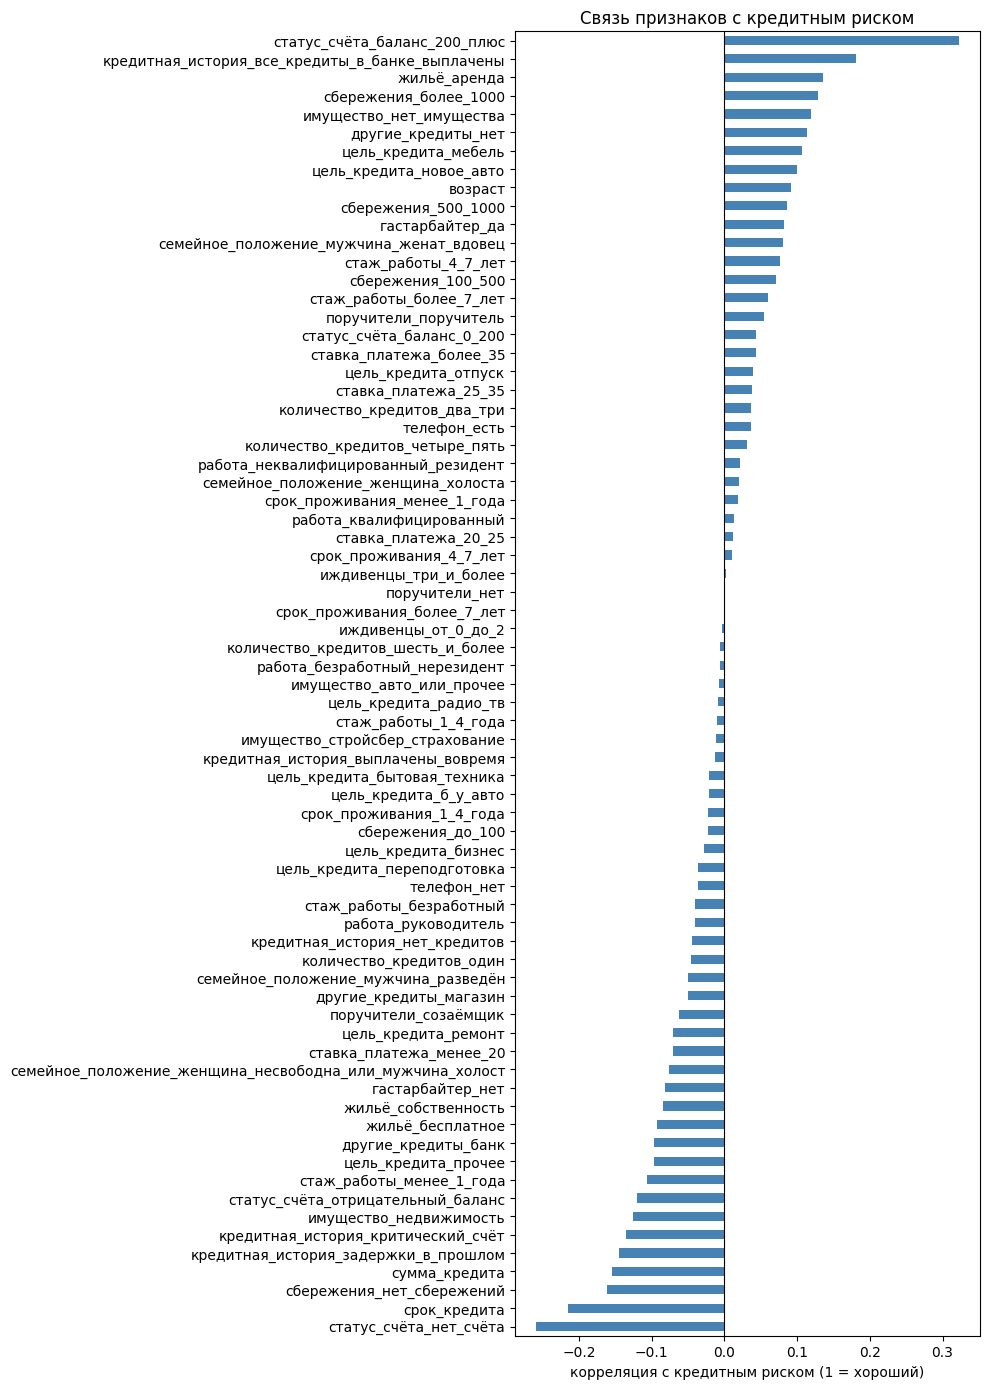

In [16]:
import matplotlib.pyplot as plt

target_col = 'кредитный_риск'

corr = data.drop(columns=[target_col]).corrwith(data[target_col])
corr = corr.sort_values()

# 3. Рисуем
fig, ax = plt.subplots(figsize=(10, 14))
corr.plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('корреляция с кредитным риском (1 = хороший)')
ax.set_title('Связь признаков с кредитным риском')
plt.tight_layout()
plt.show()